In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv("../data/processed/clean_nav.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(nav.shape)
print(performance.shape)
print(benchmark.shape)

(46000, 3)
(40, 19)
(8050, 3)


In [2]:
print(nav.columns.tolist())
print(benchmark.columns.tolist())

['amfi_code', 'date', 'nav']
['date', 'index_name', 'close_value']


In [3]:
#Task 1 - Daily returns
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)
nav.head()

annual_returns = []

for code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()
    n = len(returns)
    annual_return = (
        (1 + returns).prod()
    ) ** (252/n) - 1
    annual_returns.append(
        [code, annual_return]
    )

annual_returns = pd.DataFrame(
    annual_returns,
    columns=[
        "amfi_code",
        "annualized_return"
    ]
)
annual_returns.head()

,amfi_code,annualized_return
0,100016,0.025435
1,100025,0.042987
2,100033,0.289279
3,101206,0.226265
4,101207,0.076502


In [4]:
annual_returns.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)

In [5]:
#Task 2 - CAGR
cagr_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    start_nav = group["nav"].iloc[0]
    end_nav = group["nav"].iloc[-1]

    years = (
        group["date"].max() -
        group["date"].min()
    ).days / 365

    cagr = (
        end_nav / start_nav
    ) ** (1/years) - 1

    cagr_results.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [6]:
cagr_df.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)

In [7]:
#Task 3 - Sharpe Ratio
rf = 0.065
sharpe_list = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    annual_return = returns.mean()*252

    annual_volatility = (
        returns.std()
        * np.sqrt(252)
    )

    sharpe = (
        annual_return - rf
    ) / annual_volatility

    sharpe_list.append(
        [code,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [8]:
sharpe_df.to_csv(
    "../data/processed/sharpe_values.csv",
    index=False
)

In [9]:
#Task 4 - Sortino Ratio
sortino_list = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    annual_return = (
        returns.mean()*252
    )

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    sortino = (
        annual_return - rf
    ) / downside_std

    sortino_list.append(
        [code,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [10]:
sortino_df.to_csv(
    "../data/processed/sortino_values.csv",
    index=False
)

In [11]:
print(nav.columns.tolist())

print(benchmark.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']
['date', 'index_name', 'close_value']


In [15]:
from scipy.stats import linregress

benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [16]:
alpha_beta = []

for code, group in nav.groupby("amfi_code"):

    merged = pd.merge(
        group,
        nifty100[["date","benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = slope
        alpha = intercept * 252

        alpha_beta.append(
            [code, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [17]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully")

alpha_beta.csv saved successfully


In [18]:
#Task 6 - Maximun Drawdown
max_dd_list = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    running_max = group["nav"].cummax()

    drawdown = (
        group["nav"] / running_max
    ) - 1

    max_dd = drawdown.min()

    max_dd_list.append([
        code,
        max_dd
    ])

max_dd_df = pd.DataFrame(
    max_dd_list,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

max_dd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [19]:
max_dd_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved successfully")

max_drawdown.csv saved successfully


In [20]:
#Task 7 - Fund Scorecard
scorecard = performance.copy()

scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    max_dd_df,
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha_x,...,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,sharpe_ratio_y,alpha_y,beta_y,max_drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,14.0,-21.70,14288,1.54,4,Moderate,1.208267,0.232010,-0.031751,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,14.0,-24.43,1231,0.66,3,Moderate,0.953279,0.198686,-0.026159,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,25.0,-13.35,19259,1.43,5,Very High,0.945308,0.303370,-0.023196,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,25.0,-24.78,36061,0.72,4,Very High,-0.057187,0.048824,0.062002,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,4.0,-2.30,24101,0.77,5,Low,-0.226575,0.056209,-0.006414,-0.043287


In [24]:
scorecard["return_rank"] = scorecard[
    "return_3yr_pct"
].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard[
    "sharpe_ratio_y"
].rank(ascending=False)

scorecard["alpha_rank"] = scorecard[
    "alpha_y"
].rank(ascending=False)

scorecard["expense_rank"] = scorecard[
    "expense_ratio_pct"
].rank(ascending=True)

scorecard["dd_rank"] = scorecard[
    "max_drawdown"
].rank(ascending=False)

In [25]:
scorecard["fund_score"] = (
    scorecard["return_rank"] * 0.30 +
    scorecard["sharpe_rank"] * 0.25 +
    scorecard["alpha_rank"] * 0.20 +
    scorecard["expense_rank"] * 0.15 +
    scorecard["dd_rank"] * 0.10
)

scorecard["fund_score"] = (
    100 *
    (
        scorecard["fund_score"].max()
        -
        scorecard["fund_score"]
    )
    /
    (
        scorecard["fund_score"].max()
        -
        scorecard["fund_score"].min()
    )
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard[
    [
        "amfi_code",
        "scheme_name",
        "fund_score"
    ]
].head(10)

,amfi_code,scheme_name,fund_score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,98.143852
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,93.039443
2,119598,SBI Small Cap Fund - Regular Plan - Growth,91.879350
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,90.719258
39,149324,DSP Small Cap Fund - Regular - Growth,80.858469
38,149323,DSP Midcap Fund - Regular - Growth,78.190255
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,76.334107
26,119094,Axis Midcap Fund - Regular - Growth,74.941995
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,67.401392


In [26]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved Successfully")

Fund Scorecard Saved Successfully


In [27]:
#Task 8 - BenchMark Comparison chart
top5 = scorecard.head(5)["amfi_code"].tolist()

top5

[120505, 120843, 100033, 119598, 148567]

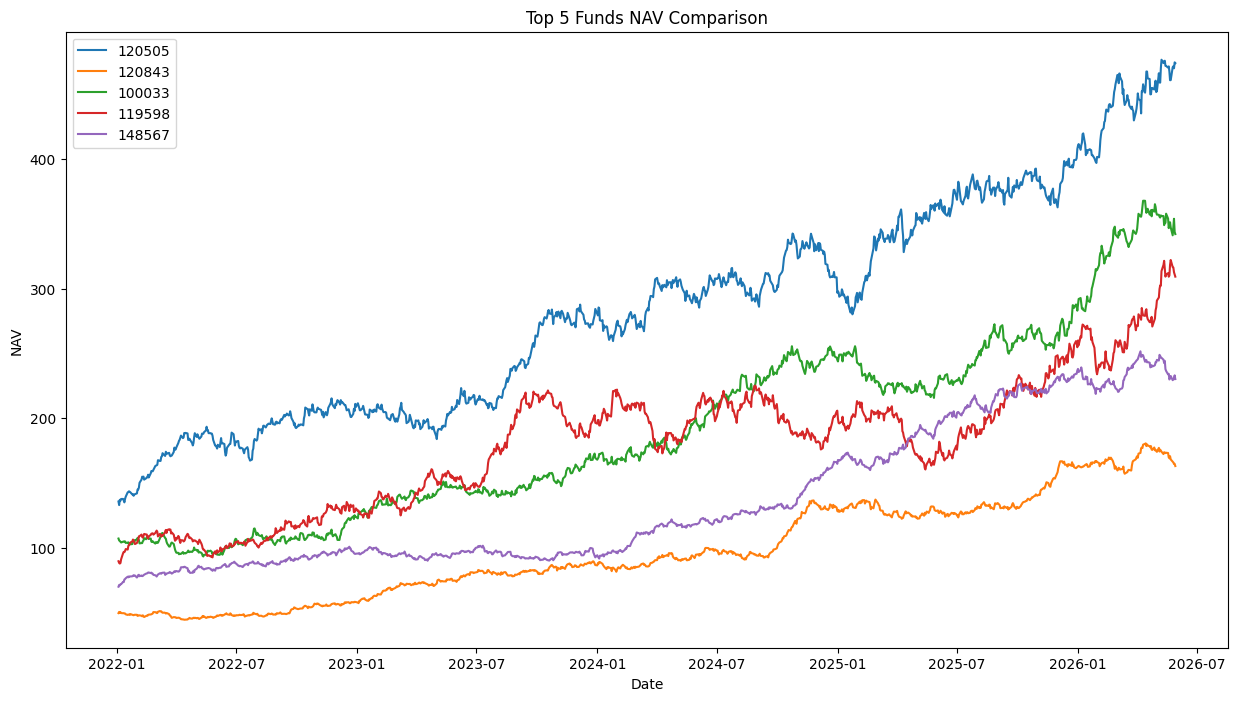

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

for code in top5:

    fund = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        fund["date"],
        fund["nav"],
        label=str(code)
    )

plt.title(
    "Top 5 Funds NAV Comparison"
)

plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()

plt.show()

In [29]:
tracking_errors = []

for code, group in nav.groupby("amfi_code"):

    merged = pd.merge(
        group,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        diff = (
            merged["daily_return"]
            -
            merged["benchmark_return"]
        )

        tracking_error = diff.std() * np.sqrt(252)

        tracking_errors.append([
            code,
            tracking_error
        ])

tracking_error_df = pd.DataFrame(
    tracking_errors,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df.head()

,amfi_code,tracking_error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


In [30]:
tracking_error_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

print("tracking_error.csv saved successfully")

tracking_error.csv saved successfully
